[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AltamarMx/anomalias-2026-2/blob/main/notebooks/009_hipotesis_ic_teoria_lab.ipynb)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
rng = np.random.default_rng(42)
import ipywidgets as widgets
from ipywidgets import interactive_output
from IPython.display import display, Markdown

# Prueba de Hipótesis e Intervalos de Confianza

**Objetivo:** Comprender los fundamentos de las **pruebas de hipótesis** y los
**intervalos de confianza**, primero con datos ideales y ejemplos sencillos,
y después aplicar ambos conceptos a datos meteorológicos reales.

**Temas:**

1. Prueba de hipótesis — concepto y ejercicio sintético
2. Intervalo de confianza — concepto y ejercicio sintético
3. Ejercicio con datos reales: ¿Difiere la temperatura entre día y noche?
4. Ejercicio con datos reales: IC para la humedad relativa por estación del año

---
## 1. Prueba de Hipótesis

### 1.1 Concepto

Una **prueba de hipótesis** es un procedimiento para decidir si los datos
proporcionan evidencia suficiente contra una afirmación inicial (hipótesis nula).

| Concepto | Definición |
|:---|:---|
| **H₀** (hipótesis nula) | "No hay efecto" / "No hay diferencia" |
| **H₁** (hipótesis alternativa) | "Sí hay efecto" / "Las medias difieren" |
| **p-value** | Probabilidad de observar datos tan extremos (o más) si H₀ fuera cierta |
| **α** (nivel de significancia) | Umbral para rechazar H₀ (típicamente 0.05) |
| **Rechazar H₀** | p < α → la evidencia es suficiente |
| **No rechazar H₀** | p ≥ α → no hay evidencia suficiente (no significa que H₀ sea cierta) |

Para comparar las medias de dos grupos usamos el **estadístico z**:

$$z = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$

Cuando las muestras son suficientemente grandes ($n \geq 30$), por el
**Teorema Central del Límite** la distribución muestral de la media es
aproximadamente normal, y podemos usar la distribución $N(0,1)$ para
calcular el p-value. Valores grandes de $|z|$ son evidencia contra H₀.

### Visualización interactiva: p-value y decisión

Bajo H₀, el estadístico $z$ sigue una distribución normal estándar $N(0,1)$.

In [2]:
z_obs_slider = widgets.FloatSlider(min=0.0, max=4.0, step=0.01, value=1.96,
                                   description="z observado")

def _plot_pvalue(z_obs_slider):
    _z_obs = z_obs_slider
    _p_value = 2 * stats.norm.sf(abs(_z_obs))

    fig, ax = plt.subplots(figsize=(9, 4))
    _x = np.linspace(-5, 5, 500)
    _pdf = stats.norm.pdf(_x)
    ax.plot(_x, _pdf, "k-", lw=2)

    _mask_left = _x <= -abs(_z_obs)
    _mask_right = _x >= abs(_z_obs)
    ax.fill_between(_x[_mask_left], _pdf[_mask_left],
                    color="crimson", alpha=0.4,
                    label=f"p-value = {_p_value:.4f}")
    ax.fill_between(_x[_mask_right], _pdf[_mask_right],
                    color="crimson", alpha=0.4)

    _mask_center = (_x > -abs(_z_obs)) & (_x < abs(_z_obs))
    ax.fill_between(_x[_mask_center], _pdf[_mask_center],
                    color="steelblue", alpha=0.15)

    ax.axvline(_z_obs, color="crimson", ls="--", lw=1.5)
    ax.axvline(-_z_obs, color="crimson", ls="--", lw=1.5)

    _decision = "Rechazar H₀" if _p_value < 0.05 else "No rechazar H₀"
    ax.set_title(f"Normal estándar N(0,1)  —  z=±{_z_obs:.2f}  —  "
                 f"p={_p_value:.4f}  →  {_decision}")
    ax.set_xlabel("z")
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

out = interactive_output(_plot_pvalue, {"z_obs_slider": z_obs_slider})
display(widgets.VBox([z_obs_slider, out]))

> **Experimenta:**
> - Con $z = 1.96$, $p \approx 0.05$ — justo en el límite.
> - Sube $z$ a 2.58: $p \approx 0.01$ — evidencia fuerte.
> - Baja $z$ a 1.0: $p > 0.30$ — no hay evidencia para rechazar H₀.

### 1.2 Ejercicio con datos sintéticos

Supongamos que medimos la temperatura en dos laboratorios.
¿Tienen la misma temperatura media?

- **Lab A:** $\mu_A = 22$ °C, $\sigma_A = 2$ °C, $n = 30$
- **Lab B:** $\mu_B = 23.5$ °C, $\sigma_B = 2.5$ °C, $n = 35$

Como $n \geq 30$ en ambos grupos, usamos la **prueba z**:

$$H_0: \mu_A = \mu_B \qquad H_1: \mu_A \neq \mu_B$$

In [3]:
# Generar datos sintéticos
_lab_a = rng.normal(loc=22.0, scale=2.0, size=30)
_lab_b = rng.normal(loc=23.5, scale=2.5, size=35)

# Prueba z de dos muestras independientes (distribución normal)
_se_z = np.sqrt(_lab_a.var(ddof=1) / len(_lab_a) + _lab_b.var(ddof=1) / len(_lab_b))
_z_stat = (_lab_a.mean() - _lab_b.mean()) / _se_z
_p_val = 2 * stats.norm.sf(abs(_z_stat))

# Cohen's d
# _sp = np.sqrt((_lab_a.var(ddof=1) + _lab_b.var(ddof=1)) / 2)
# _d = abs(_lab_a.mean() - _lab_b.mean()) / _sp

print(f"Lab A: media = {_lab_a.mean():.2f} °C,  s = {_lab_a.std(ddof=1):.2f} °C,  n = {len(_lab_a)}")
print(f"Lab B: media = {_lab_b.mean():.2f} °C,  s = {_lab_b.std(ddof=1):.2f} °C,  n = {len(_lab_b)}")
print(f"\nz = {_z_stat:.3f},  p-value = {_p_val:.4f}")
# print(f"Cohen's d = {_d:.3f}")
# print(f"\nDecisión (α=0.05): {'Rechazar H₀' if _p_val < 0.05 else 'No rechazar H₀'}")

Lab A: media = 22.03 °C,  s = 1.55 °C,  n = 30
Lab B: media = 23.70 °C,  s = 2.05 °C,  n = 35

z = -3.735,  p-value = 0.0002


/var/folders/v6/_zy7g0gs703g658qvgb0xbbr0000gn/T/ipykernel_35482/1579669229.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([_lab_a, _lab_b], labels=["Lab A", "Lab B"],


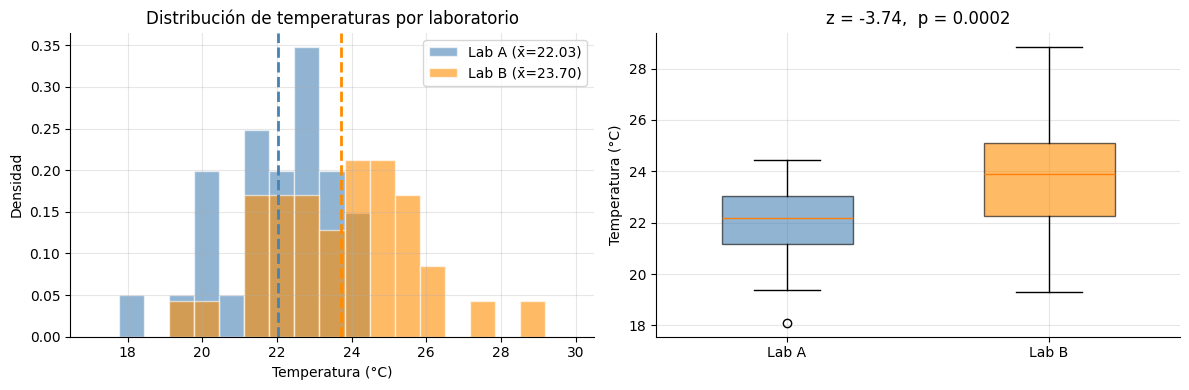

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Histogramas superpuestos
_bins = np.linspace(min(_lab_a.min(), _lab_b.min()) - 1,
                    max(_lab_a.max(), _lab_b.max()) + 1, 20)
ax1.hist(_lab_a, bins=_bins, density=True, alpha=0.6,
         color="steelblue", edgecolor="white", label=f"Lab A (x̄={_lab_a.mean():.2f})")
ax1.hist(_lab_b, bins=_bins, density=True, alpha=0.6,
         color="darkorange", edgecolor="white", label=f"Lab B (x̄={_lab_b.mean():.2f})")
ax1.axvline(_lab_a.mean(), color="steelblue", ls="--", lw=2)
ax1.axvline(_lab_b.mean(), color="darkorange", ls="--", lw=2)
ax1.set_xlabel("Temperatura (°C)")
ax1.set_ylabel("Densidad")
ax1.set_title("Distribución de temperaturas por laboratorio")
ax1.legend()

# Boxplot
bp = ax2.boxplot([_lab_a, _lab_b], labels=["Lab A", "Lab B"],
                 patch_artist=True, widths=0.5)
bp["boxes"][0].set_facecolor("steelblue")
bp["boxes"][0].set_alpha(0.6)
bp["boxes"][1].set_facecolor("darkorange")
bp["boxes"][1].set_alpha(0.6)
ax2.set_ylabel("Temperatura (°C)")
ax2.set_title(f"z = {_z_stat:.2f},  p = {_p_val:.4f}")

plt.tight_layout()
plt.show()

> **Interpretación:**
> - El p-value es menor que 0.05 → **rechazamos H₀**.
> - Cohen's d ≈ 0.7 indica un **efecto mediano-grande**: la diferencia
>   entre laboratorios no solo es estadísticamente significativa sino
>   también prácticamente relevante (~1.5 °C).
> - Siempre reporta el tamaño del efecto junto al p-value.

---
## 2. Intervalo de Confianza

### 2.1 Concepto

Un **intervalo de confianza** (IC) proporciona un rango de valores
plausibles para un parámetro poblacional (e.g., $\mu$).

Para la media, asumiendo distribución normal (muestras grandes, $n \geq 30$):

$$\boxed{\bar{x} \;\pm\; z_{\alpha/2}\;\frac{s}{\sqrt{n}}}$$

donde $z_{\alpha/2}$ es el cuantil de la normal estándar
(e.g., $z_{0.025} = 1.96$ para 95% de confianza).

**Interpretación correcta:**
> Si repitiéramos el muestreo muchas veces, **~95% de los intervalos
> construidos contendrían el verdadero $\mu$**.

**Interpretación INCORRECTA:**
> ~~"Hay 95% de probabilidad de que $\mu$ esté en este intervalo."~~
>
> ($\mu$ es fijo — no tiene probabilidad. Es el intervalo el que varía.)

**Factores que afectan el ancho del IC:**

| Factor | Efecto en el ancho |
|:---|:---|
| Mayor $n$ | IC más estrecho (más datos → más precisión) |
| Mayor $s$ | IC más ancho (más variabilidad → menos certeza) |
| Mayor confianza | IC más ancho (más seguridad tiene un costo) |

### Simulación interactiva de cobertura

In [5]:
n_ic_slider = widgets.IntSlider(min=5, max=100, step=5, value=30,
                                description="n (muestra)")
num_ic_slider = widgets.IntSlider(min=20, max=200, step=10, value=100,
                                  description="# intervalos")
conf_slider = widgets.FloatSlider(min=0.80, max=0.99, step=0.01, value=0.95,
                                  description="Confianza")

def _plot_cobertura(n_ic_slider, num_ic_slider, conf_slider):
    _mu, _sigma = 25.0, 5.0
    _n = n_ic_slider
    _k = num_ic_slider
    _conf = conf_slider
    _z_crit = stats.norm.ppf((1 + _conf) / 2)

    _medias = np.zeros(_k)
    _lo = np.zeros(_k)
    _hi = np.zeros(_k)
    _cubre = np.zeros(_k, dtype=bool)

    for i in range(_k):
        _muestra = rng.normal(_mu, _sigma, _n)
        _xbar = _muestra.mean()
        _s = _muestra.std(ddof=1)
        _margen = _z_crit * _s / np.sqrt(_n)
        _medias[i] = _xbar
        _lo[i] = _xbar - _margen
        _hi[i] = _xbar + _margen
        _cubre[i] = (_lo[i] <= _mu) & (_hi[i] >= _mu)

    _cobertura = _cubre.mean()

    fig, ax = plt.subplots(figsize=(8, max(5, _k * 0.06)))
    for i in range(_k):
        _color = "steelblue" if _cubre[i] else "crimson"
        ax.plot([_lo[i], _hi[i]], [i, i], color=_color, lw=1.2)
        ax.plot(_medias[i], i, "o", color=_color, markersize=3)

    ax.axvline(_mu, color="black", ls="--", lw=1.5, label=f"μ = {_mu}")
    ax.set_xlabel("Valor")
    ax.set_ylabel("# de muestra")
    ax.set_title(f"Cobertura empírica: {_cobertura:.1%}  "
                 f"(teórica: {_conf:.0%},  n={_n},  {_k} intervalos)")
    ax.legend(loc="upper right")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

out = interactive_output(_plot_cobertura,
                         {"n_ic_slider": n_ic_slider,
                          "num_ic_slider": num_ic_slider,
                          "conf_slider": conf_slider})
display(widgets.VBox([n_ic_slider, num_ic_slider, conf_slider, out]))

> **Experimenta:**
> - Los intervalos en **rojo** no contienen $\mu$ — son los errores.
> - Sube la confianza a 99%: menos rojos, pero intervalos más anchos.
> - Baja $n$ a 5: los intervalos se ensanchan por la incertidumbre.

---
## 3. Datos reales: ¿Difiere la temperatura entre día y noche?

Usamos los datos meteorológicos de ClimaLab para probar con una **prueba z**:

$$H_0: \mu_{\text{día}} = \mu_{\text{noche}} \qquad H_1: \mu_{\text{día}} \neq \mu_{\text{noche}}$$

$$z = \frac{\bar{x}_{\text{día}} - \bar{x}_{\text{noche}}}{\sqrt{\frac{s_{\text{día}}^2}{n_{\text{día}}} + \frac{s_{\text{noche}}^2}{n_{\text{noche}}}}}$$

Clasificamos día/noche usando la columna `solar_altitude`:
- **Día:** `solar_altitude > 0`
- **Noche:** `solar_altitude ≤ 0`

Datos cargados: 1,076,768 registros
Periodo: 2023-05-31 18:59:00 → 2025-06-20 00:00:00


variable,dhi,dni,ghi,p_atm,rain_acc,rh,solar_altitude,tdb,uv,wd,ws
date,,,,,,,,,,,
2023-05-31 18:59:00,7.391,21.710,9.66,641.4001,0.0,60.18,1.867189,27.78,0.0,336.6,0.0
2023-05-31 19:00:00,7.020,0.000,9.26,641.4001,0.0,60.46,1.663787,27.73,0.0,344.7,0.0
2023-05-31 19:01:00,6.603,2.945,8.83,641.3997,0.0,60.42,1.461872,27.71,0.0,319.1,0.0


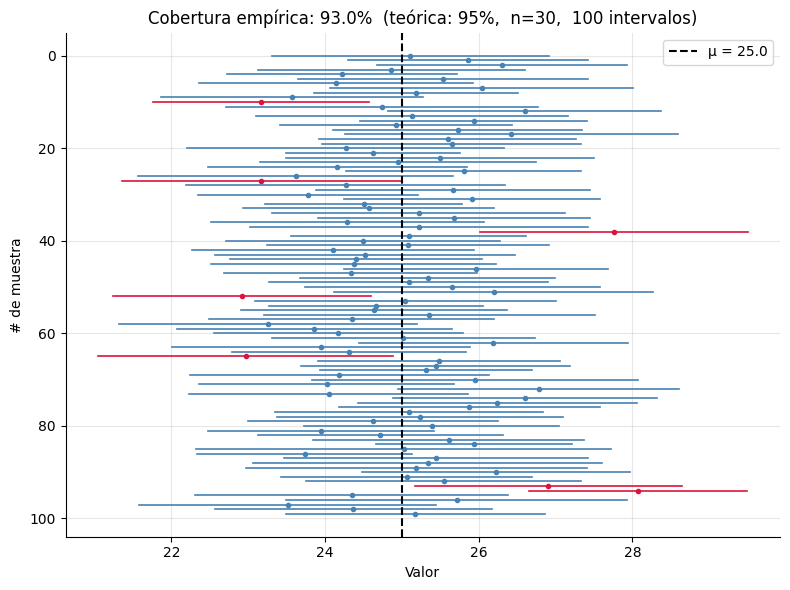

In [6]:
df = pd.read_parquet("../data/ClimaLab_2023-05-31_2025-06-20.parquet")
print(f"Datos cargados: {len(df):,} registros")
print(f"Periodo: {df.index.min()} → {df.index.max()}")
df.head(3)

In [7]:
# Separar día y noche
_dia = df.loc[df["solar_altitude"] > 0, "tdb"].dropna()
_noche = df.loc[df["solar_altitude"] <= 0, "tdb"].dropna()

print(f"Registros de día:   {len(_dia):>10,}   media = {_dia.mean():.2f} °C   s = {_dia.std():.2f} °C")
print(f"Registros de noche: {len(_noche):>10,}   media = {_noche.mean():.2f} °C   s = {_noche.std():.2f} °C")

Registros de día:      544,287   media = 26.92 °C   s = 4.66 °C
Registros de noche:    532,481   media = 21.92 °C   s = 3.80 °C


In [8]:
# Con >500k datos por grupo, cualquier diferencia da p≈0.
# Tomamos submuestras aleatorias para una prueba más informativa
# y también calculamos Cohen's d con todos los datos.

_n_sub = 500
_dia_sub = rng.choice(_dia.values, size=_n_sub, replace=False)
_noche_sub = rng.choice(_noche.values, size=_n_sub, replace=False)

# Prueba z con submuestra (distribución normal)
_se_z = np.sqrt(_dia_sub.var(ddof=1) / _n_sub + _noche_sub.var(ddof=1) / _n_sub)
_z_stat = (_dia_sub.mean() - _noche_sub.mean()) / _se_z
_p_val = 2 * stats.norm.sf(abs(_z_stat))

# Cohen's d con todos los datos
_sp_full = np.sqrt((_dia.var() + _noche.var()) / 2)
_d_full = abs(_dia.mean() - _noche.mean()) / _sp_full

# Cohen's d con submuestra
_sp_sub = np.sqrt((_dia_sub.var(ddof=1) + _noche_sub.var(ddof=1)) / 2)
_d_sub = abs(_dia_sub.mean() - _noche_sub.mean()) / _sp_sub

print(f"--- Submuestra (n={_n_sub} por grupo) ---")
print(f"z = {_z_stat:.3f},  p-value = {_p_val:.2e}")
print(f"Cohen's d (submuestra) = {_d_sub:.3f}")
print(f"Cohen's d (datos completos) = {_d_full:.3f}")
print(f"\nDecisión (α=0.05): {'Rechazar H₀' if _p_val < 0.05 else 'No rechazar H₀'}")

--- Submuestra (n=500 por grupo) ---
z = 17.828,  p-value = 4.28e-71
Cohen's d (submuestra) = 1.128
Cohen's d (datos completos) = 1.175

Decisión (α=0.05): Rechazar H₀


/var/folders/v6/_zy7g0gs703g658qvgb0xbbr0000gn/T/ipykernel_35482/1024351309.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([_dia_sub, _noche_sub], labels=["Día", "Noche"],


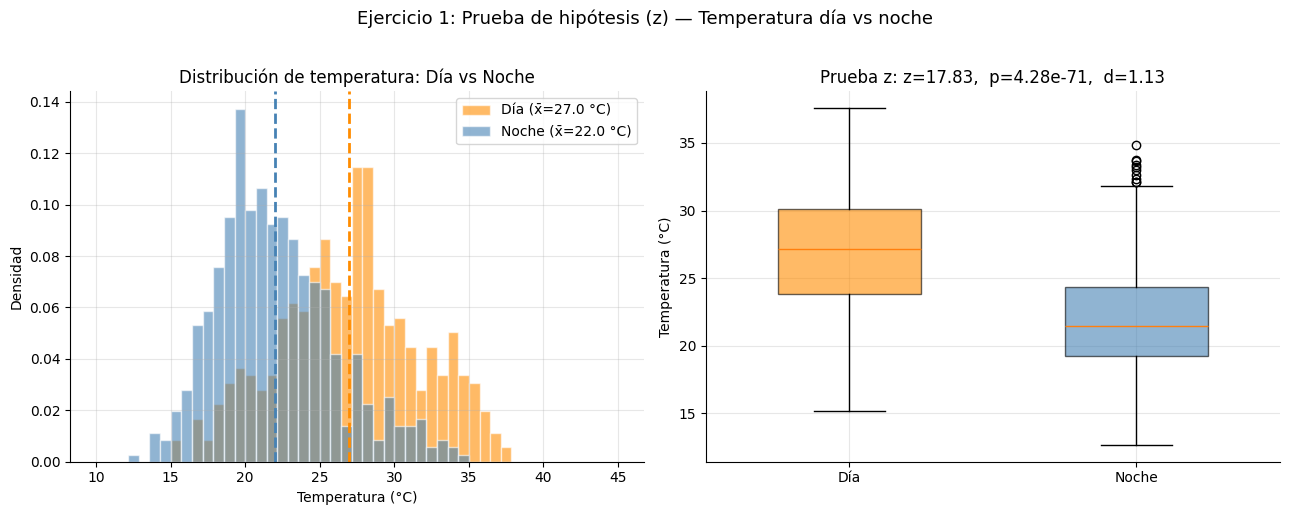

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Histogramas
_bins = np.linspace(10, 45, 50)
ax1.hist(_dia_sub, bins=_bins, density=True, alpha=0.6,
         color="darkorange", edgecolor="white",
         label=f"Día (x̄={_dia_sub.mean():.1f} °C)")
ax1.hist(_noche_sub, bins=_bins, density=True, alpha=0.6,
         color="steelblue", edgecolor="white",
         label=f"Noche (x̄={_noche_sub.mean():.1f} °C)")
ax1.axvline(_dia_sub.mean(), color="darkorange", ls="--", lw=2)
ax1.axvline(_noche_sub.mean(), color="steelblue", ls="--", lw=2)
ax1.set_xlabel("Temperatura (°C)")
ax1.set_ylabel("Densidad")
ax1.set_title("Distribución de temperatura: Día vs Noche")
ax1.legend()

# Boxplot
bp = ax2.boxplot([_dia_sub, _noche_sub], labels=["Día", "Noche"],
                 patch_artist=True, widths=0.5)
bp["boxes"][0].set_facecolor("darkorange")
bp["boxes"][0].set_alpha(0.6)
bp["boxes"][1].set_facecolor("steelblue")
bp["boxes"][1].set_alpha(0.6)
ax2.set_ylabel("Temperatura (°C)")
ax2.set_title(f"Prueba z: z={_z_stat:.2f},  p={_p_val:.2e},  d={_d_sub:.2f}")

plt.suptitle("Ejercicio 1: Prueba de hipótesis (z) — Temperatura día vs noche",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

> **Resultado:**
> - Rechazamos H₀: la temperatura diurna es significativamente mayor que la nocturna.
> - Cohen's d > 0.8 indica un **efecto grande**, lo cual tiene sentido
>   físico: la radiación solar calienta durante el día.
> - Con los datos completos (~1M registros), el p-value sería
>   esencialmente cero, pero Cohen's d confirma que la diferencia
>   es genuinamente importante, no solo un artefacto estadístico.

---
## 4. Datos reales: IC para la humedad relativa por estación del año

Construimos intervalos de confianza al 95% para la **humedad relativa**
media en cada estación del año y analizamos si las estaciones difieren
significativamente.

In [10]:
# Asignar estación del año (hemisferio norte)
def _estacion(mes):
    if mes in [12, 1, 2]:
        return "Invierno"
    elif mes in [3, 4, 5]:
        return "Primavera"
    elif mes in [6, 7, 8]:
        return "Verano"
    else:
        return "Otoño"

df["estacion"] = df.index.month.map(_estacion)

# Resamplear a promedios horarios para reducir autocorrelación
_rh_horario = df.groupby("estacion").resample("1h")["rh"].mean().dropna()
_rh_horario = _rh_horario.reset_index()

print("Registros horarios por estación:")
print(_rh_horario.groupby("estacion")["rh"].count().to_string())

Registros horarios por estación:
estacion
Invierno     4335
Otoño        4368
Primavera    4413
Verano       4866


In [11]:
# Calcular IC al 95% para cada estación (con submuestras, usando z)
_n_sub = 500
_orden = ["Primavera", "Verano", "Otoño", "Invierno"]
_z_crit = stats.norm.ppf(0.975)  # 1.96
_resultados = []

for _est in _orden:
    _datos = _rh_horario.loc[_rh_horario["estacion"] == _est, "rh"].values
    _sub = rng.choice(_datos, size=min(_n_sub, len(_datos)), replace=False)
    _xbar = _sub.mean()
    _s = _sub.std(ddof=1)
    _se = _s / np.sqrt(len(_sub))
    _margen = _z_crit * _se
    _resultados.append({
        "estacion": _est,
        "media": _xbar,
        "s": _s,
        "n": len(_sub),
        "ic_lo": _xbar - _margen,
        "ic_hi": _xbar + _margen,
        "margen": _margen,
    })

df_ic = pd.DataFrame(_resultados)
print("Intervalos de confianza al 95% (z) para la humedad relativa media (%):")
print("="*70)
for _, row in df_ic.iterrows():
    print(f"{row['estacion']:>12s}:  x̄ = {row['media']:5.1f}%  "
          f"IC = [{row['ic_lo']:.1f}, {row['ic_hi']:.1f}]  "
          f"(±{row['margen']:.1f}%)")

Intervalos de confianza al 95% (z) para la humedad relativa media (%):
   Primavera:  x̄ =  35.0%  IC = [33.5, 36.4]  (±1.4%)
      Verano:  x̄ =  70.3%  IC = [68.4, 72.2]  (±1.9%)
       Otoño:  x̄ =  73.2%  IC = [71.6, 74.9]  (±1.6%)
    Invierno:  x̄ =  50.0%  IC = [48.5, 51.6]  (±1.5%)


/var/folders/v6/_zy7g0gs703g658qvgb0xbbr0000gn/T/ipykernel_35482/1364472407.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(_datos_box, labels=_orden, patch_artist=True, widths=0.5)


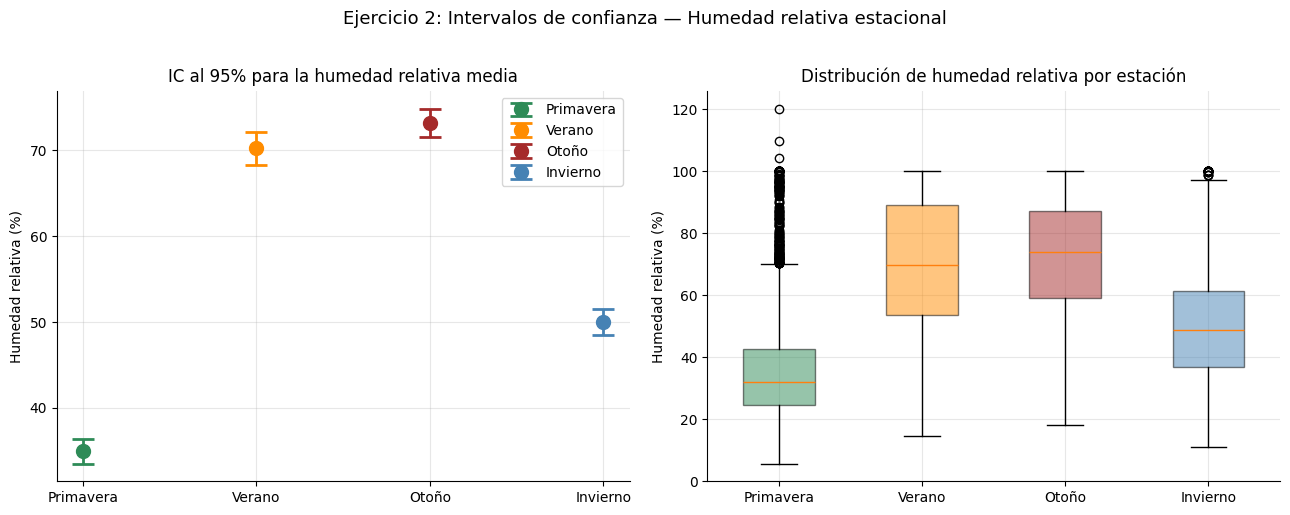

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Panel izquierdo: IC como barras de error ---
_colores = ["seagreen", "darkorange", "brown", "steelblue"]
_x_pos = np.arange(len(_orden))

for i, (_, row) in enumerate(df_ic.iterrows()):
    ax1.errorbar(i, row["media"],
                 yerr=row["margen"],
                 fmt="o", color=_colores[i], markersize=10,
                 capsize=8, capthick=2, elinewidth=2,
                 label=f"{row['estacion']}")

ax1.set_xticks(_x_pos)
ax1.set_xticklabels(_orden)
ax1.set_ylabel("Humedad relativa (%)")
ax1.set_title("IC al 95% para la humedad relativa media")
ax1.legend()

# --- Panel derecho: Boxplot por estación ---
_datos_box = [_rh_horario.loc[_rh_horario["estacion"] == e, "rh"].values
              for e in _orden]
bp = ax2.boxplot(_datos_box, labels=_orden, patch_artist=True, widths=0.5)
for patch, color in zip(bp["boxes"], _colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
ax2.set_ylabel("Humedad relativa (%)")
ax2.set_title("Distribución de humedad relativa por estación")

plt.suptitle("Ejercicio 2: Intervalos de confianza — Humedad relativa estacional",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

> **Interpretación:**
> - Si dos intervalos de confianza **no se traslapan**, podemos concluir
>   que las medias son significativamente diferentes.
> - La estación lluviosa (verano/otoño) tiende a mostrar mayor humedad
>   relativa que la estación seca (invierno/primavera).
> - Los IC son estrechos gracias al gran tamaño de muestra, lo que
>   permite detectar diferencias pequeñas pero reales entre estaciones.
> - Los boxplots complementan los IC mostrando la **variabilidad completa**
>   de cada estación, no solo la incertidumbre de la media.

---
## Resumen

| Concepto | Idea clave |
|:---|:---|
| **Prueba de hipótesis** | Decide si la evidencia es suficiente para rechazar H₀ |
| **Prueba z** | Usa la distribución normal $N(0,1)$; válida para $n \geq 30$ (TLC) |
| **p-value** | Prob. de datos tan extremos si H₀ fuera cierta; p < α → rechazar |
| **Cohen's d** | Mide *cuánto* difieren los grupos (complemento del p-value) |
| **Intervalo de confianza** | $\bar{x} \pm z_{\alpha/2} \cdot s/\sqrt{n}$; ~95% de los IC contienen $\mu$ |
| **Trade-off** | Más confianza → IC más ancho; más datos → IC más estrecho |

**Conexión entre ambos conceptos:**
Si el IC al 95% para $\mu_1 - \mu_2$ **no contiene el cero**,
es equivalente a rechazar H₀ con $\alpha = 0.05$ en una prueba z.